In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
transactions = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")

In [5]:
import pandas as pd
import numpy as np

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [6]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']


In [7]:
var_cvar = []

for fund, grp in nav.groupby("amfi_code"):

    returns = grp["daily_return"].dropna()

    var95 = returns.quantile(0.05)

    cvar95 = returns[returns <= var95].mean()

    var_cvar.append(
        [fund, var95, cvar95]
    )

var_cvar_df = pd.DataFrame(
    var_cvar,
    columns=["amfi_code", "VaR_95", "CVaR_95"]
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [8]:
var_cvar_df.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

In [9]:
var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


Rolling 90-Day Sharpe Ratio

In [10]:
perf = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")

perf.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade']

In [11]:
perf[["amfi_code","scheme_name"]].head()

,amfi_code,scheme_name
0,119551,SBI Bluechip Fund - Regular Plan - Growth
1,119552,SBI Bluechip Fund - Direct Plan - Growth
2,119598,SBI Small Cap Fund - Regular Plan - Growth
3,119599,SBI Small Cap Fund - Direct Plan - Growth
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth


In [12]:
perf.columns.tolist()

['amfi_code',
 'scheme_name',
 'fund_house',
 'category',
 'plan',
 'return_1yr_pct',
 'return_3yr_pct',
 'return_5yr_pct',
 'benchmark_3yr_pct',
 'alpha',
 'beta',
 'sharpe_ratio',
 'sortino_ratio',
 'std_dev_ann_pct',
 'max_drawdown_pct',
 'aum_crore',
 'expense_ratio_pct',
 'morningstar_rating',
 'risk_grade']

In [13]:
perf[["amfi_code","scheme_name"]].head()

,amfi_code,scheme_name
0,119551,SBI Bluechip Fund - Regular Plan - Growth
1,119552,SBI Bluechip Fund - Direct Plan - Growth
2,119598,SBI Small Cap Fund - Regular Plan - Growth
3,119599,SBI Small Cap Fund - Direct Plan - Growth
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth


In [14]:
top5 = (
    perf.sort_values("sharpe_ratio", ascending=False)
        .head(5)
)

top5[["amfi_code", "scheme_name", "sharpe_ratio"]]

,amfi_code,scheme_name,sharpe_ratio
14,120507,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,120844,Kotak Liquid Fund - Regular - Growth,6.18
30,101208,ABSL Liquid Fund - Regular - Growth,5.14
9,100025,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52


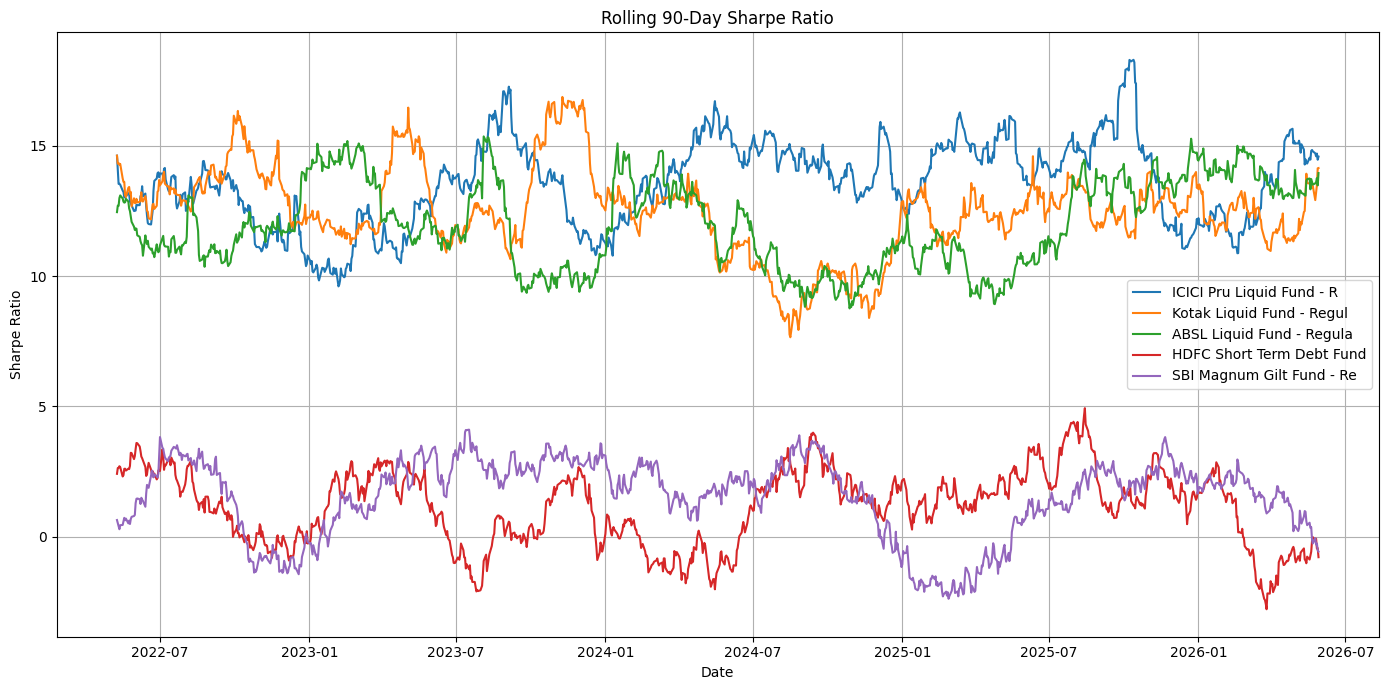

In [15]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

for fund_code in top5["amfi_code"]:

    temp = nav[nav["amfi_code"] == fund_code].copy()

    rolling_sharpe = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    fund_name = (
        top5[top5["amfi_code"] == fund_code]
        ["scheme_name"]
        .iloc[0]
    )

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=fund_name[:25]
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

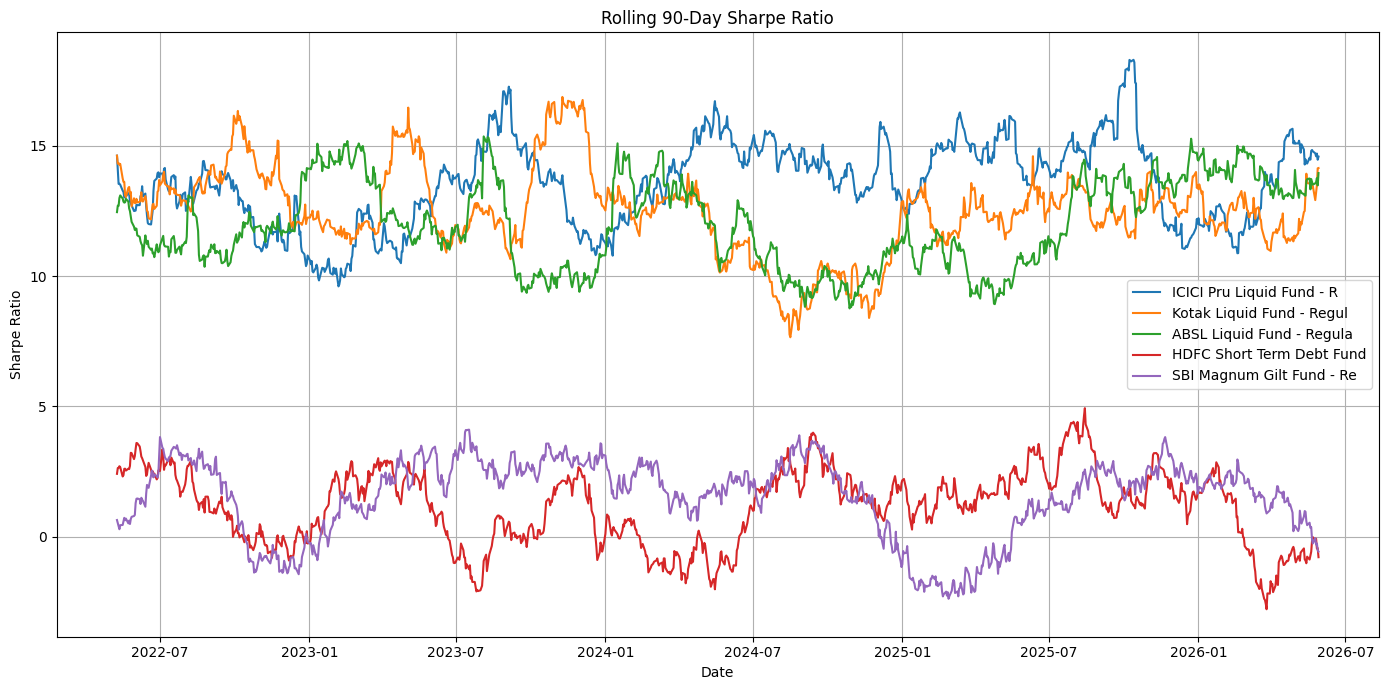

In [16]:
plt.figure(figsize=(14,7))

for fund_code in top5["amfi_code"]:

    temp = nav[nav["amfi_code"] == fund_code].copy()

    rolling_sharpe = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    fund_name = (
        top5[top5["amfi_code"] == fund_code]
        ["scheme_name"]
        .iloc[0]
    )

    plt.plot(
        temp["date"],
        rolling_sharpe,
        label=fund_name[:25]
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [17]:
top5[["scheme_name","sharpe_ratio"]]

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52


Investor Cohort Analysis

In [20]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

first_txn = (
    transactions.groupby("investor_id")
    ["transaction_date"]
    .min()
)

transactions["cohort_year"] = (
    transactions["investor_id"]
    .map(first_txn.dt.year)
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [21]:
cohort_analysis = (
    transactions.groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr","mean"),
        total_invested=("amount_inr","sum")
    )
    .reset_index()
)

cohort_analysis

,cohort_year,avg_sip_amount,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [22]:
cohort_analysis.to_csv(
    "../data/processed/cohort_analysis.csv",
    index=False
)

SIP Continuity Analysis

In [23]:
transactions = transactions.sort_values(
    ["investor_id", "transaction_date"]
)

transactions["gap_days"] = (
    transactions.groupby("investor_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,71.0
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,5.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024,107.0


In [24]:
sip_continuity = (
    transactions.groupby("investor_id")
    .agg(
        total_transactions=("transaction_date", "count"),
        avg_gap_days=("gap_days", "mean")
    )
    .reset_index()
)

In [25]:
sip_continuity = sip_continuity[
    sip_continuity["total_transactions"] >= 6
]

In [26]:
import numpy as np

sip_continuity["status"] = np.where(
    sip_continuity["avg_gap_days"] > 35,
    "At Risk",
    "Healthy"
)

sip_continuity.head()

,investor_id,total_transactions,avg_gap_days,status
1,INV000002,6,82.800000,At Risk
3,INV000004,9,53.375000,At Risk
4,INV000005,8,52.000000,At Risk
5,INV000006,6,99.000000,At Risk
7,INV000008,8,50.285714,At Risk


In [27]:
sip_continuity["status"].value_counts()

status
At Risk    2762
Healthy     188
Name: count, dtype: int64

In [28]:
sip_continuity.to_csv(
    "../data/processed/sip_continuity.csv",
    index=False
)

In [29]:
at_risk_pct = (
    2762 / (2762 + 188)
) * 100

print(at_risk_pct)

93.62711864406779


Approximately 93.6% of investors with 6+ SIP transactions were classified as "At Risk" due to average contribution gaps exceeding 35 days, indicating potential SIP discontinuation risk.

Simple Fund Recommender

In [30]:
perf["risk_grade"].unique()

<StringArray>
['Moderate', 'Very High', 'Low', 'High', 'Moderately High']
Length: 5, dtype: str

In [31]:
def recommend_funds(risk_level):

    recommendations = (
        perf[perf["risk_grade"] == risk_level]
        .sort_values("sharpe_ratio", ascending=False)
        [["scheme_name", "risk_grade", "sharpe_ratio"]]
        .head(3)
    )

    return recommendations

In [32]:
recommend_funds("Low")

,scheme_name,risk_grade,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,Low,7.68
23,Kotak Liquid Fund - Regular - Growth,Low,6.18
30,ABSL Liquid Fund - Regular - Growth,Low,5.14


In [33]:
recommend_funds("Moderate")

,scheme_name,risk_grade,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03


In [34]:
recommend_funds("High")

,scheme_name,risk_grade,sharpe_ratio
21,Kotak Emerging Equity Fund - Regular - Growth,High,0.96
12,ICICI Pru Midcap Fund - Regular - Growth,High,0.95
38,DSP Midcap Fund - Regular - Growth,High,0.90


In [35]:
recommend_funds("Very High")

,scheme_name,risk_grade,sharpe_ratio
2,SBI Small Cap Fund - Regular Plan - Growth,Very High,0.94
3,SBI Small Cap Fund - Direct Plan - Growth,Very High,0.93
29,ABSL Small Cap Fund - Regular - Growth,Very High,0.90


Sector HHI


In [37]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

print(holdings.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


In [ ]:
#Calculate HHI per Fund
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

hhi_df = (
    holdings.groupby("amfi_code")["weight_pct"]
    .apply(lambda x: ((x/100)**2).sum())
    .reset_index()
)

hhi_df.columns = ["amfi_code", "HHI"]

hhi_df.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [ ]:
#Add Fund Names
hhi_df = hhi_df.merge(
    perf[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

hhi_df.head()

,amfi_code,HHI,scheme_name
0,100016,0.139534,HDFC Top 100 Fund - Regular Plan - Growth
1,100033,0.147592,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
2,101206,0.129332,ABSL Frontline Equity Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth


In [40]:
#Most Concentrated Funds
hhi_df.sort_values(
    "HHI",
    ascending=False
).head(10)

,amfi_code,HHI,scheme_name
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth


In [41]:
#Least Concentrated Funds
hhi_df.sort_values(
    "HHI",
    ascending=True
).head(10)

,amfi_code,HHI,scheme_name
17,119598,0.107349,SBI Small Cap Fund - Regular Plan - Growth
16,119552,0.108011,SBI Bluechip Fund - Direct Plan - Growth
9,118634,0.108358,Nippon India Small Cap Fund - Regular - Growth
20,120504,0.108674,ICICI Pru Bluechip Fund - Direct - Growth
14,119095,0.109605,Axis Small Cap Fund - Regular - Growth
5,102886,0.114693,UTI Mid Cap Fund - Regular - Growth
33,149324,0.118677,DSP Small Cap Fund - Regular - Growth
15,119551,0.118716,SBI Bluechip Fund - Regular Plan - Growth
8,118633,0.121461,Nippon India Large Cap Fund - Direct - Growth
24,120842,0.127439,Kotak Emerging Equity Fund - Regular - Growth


# Advanced Insights

1. ABSL Small Cap Fund and SBI Small Cap Fund exhibited the highest downside risk based on VaR and CVaR analysis, indicating larger losses during adverse market conditions.

2. ICICI Pru Liquid Fund, Kotak Liquid Fund, and ABSL Liquid Fund achieved the highest Sharpe ratios, demonstrating superior risk-adjusted returns among all analyzed schemes.

3. The 2024 investor cohort contributed the highest total investment amount (₹349 Cr+), making it the most significant investor segment in the dataset.

4. SIP continuity analysis showed that 93.6% of investors with six or more transactions were classified as "At Risk", suggesting potential challenges in maintaining long-term SIP discipline.

5. Axis Bluechip Fund (HHI = 0.206) and ABSL Small Cap Fund (HHI = 0.201) exhibited the highest portfolio concentration, indicating greater dependence on a smaller set of sectors and holdings compared to more diversified funds.

In [42]:
hhi_df.sort_values("HHI", ascending=False).head(10)

,amfi_code,HHI,scheme_name
11,119092,0.206448,Axis Bluechip Fund - Regular - Growth
3,101207,0.200700,ABSL Small Cap Fund - Regular - Growth
18,119599,0.174751,SBI Small Cap Fund - Direct Plan - Growth
4,102885,0.174709,UTI Nifty 50 Index Fund - Regular - Growth
7,118632,0.168298,Nippon India Large Cap Fund - Regular - Growth
29,148568,0.167930,Mirae Asset Emerging Bluechip Fund - Regular -...
21,120505,0.157570,ICICI Pru Midcap Fund - Regular - Growth
22,120506,0.153794,ICICI Pru Value Discovery Fund - Regular - Growth
27,125498,0.152414,HDFC Mid-Cap Opportunities Fund - Direct - Growth
23,120841,0.149680,Kotak Bluechip Fund - Regular - Growth
